# Evaluation

Four perturbed scenarios: detection rate, mean 3D error, FPS.

## Setup

Mount Drive in Colab and install from `pyproject.toml` (`pip install -e .`).

In [1]:
import os
import runpy

_cwd = os.getcwd()
_utils = os.path.join(_cwd, "colab_utils.py")
if not os.path.isfile(_utils):
    _utils = os.path.join(_cwd, "notebooks", "colab_utils.py")
runpy.run_path(_utils)

from notebooks.colab_utils import enable_inline_matplotlib, install_requirements, setup_notebook

enable_inline_matplotlib()
PROJECT_ROOT = setup_notebook()
install_requirements(PROJECT_ROOT)

## Run scenarios

| Scenario | What changes |
|----------|----------------|
| clean | Baseline |
| rgb_noise | Gaussian noise on RGB |
| depth_noise | Gaussian noise on depth |
| occlusion | Band over cube center |

Occlusion should drop detection rate. Increase `NUM_FRAMES` for smoother averages.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from evals.run_evals import run_all_evals

NUM_FRAMES = 20
df = run_all_evals(num_frames=NUM_FRAMES)

display_cols = ["scenario", "detection_rate_pct", "mean_error_mm", "fps", "num_frames"]
df[display_cols].rename(columns={
    "detection_rate_pct": "detection_%",
    "mean_error_mm": "mean_err_mm",
})

,scenario,detection_%,mean_err_mm,fps,num_frames
0,clean,100.0,0.474871,228.0,20
1,rgb_noise,100.0,0.723397,267.7,20
2,depth_noise,100.0,0.952980,266.9,20
3,occlusion,0.0,NaN,1682.6,20


## Plot

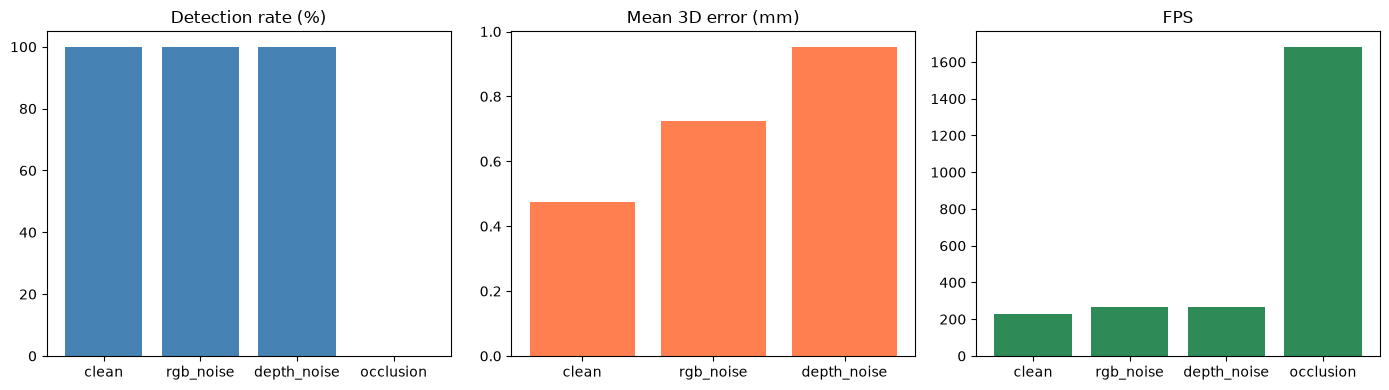

Saved /Users/noel/Documents/object-pose-estimation/assets/demo/eval_summary.png


In [3]:
import os

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(df["scenario"], df["detection_rate"] * 100, color="steelblue")
axes[0].set_title("Detection rate (%)")
axes[0].set_ylim(0, 105)

axes[1].bar(df["scenario"], df["mean_error_mm"], color="coral")
axes[1].set_title("Mean 3D error (mm)")

axes[2].bar(df["scenario"], df["fps"], color="seagreen")
axes[2].set_title("FPS")

plt.tight_layout()
out = os.path.join(PROJECT_ROOT, "assets", "demo", "eval_summary.png")
os.makedirs(os.path.dirname(out), exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

## Save

Writes `evals/results/eval_results.csv` on the project root (Drive in Colab).

In [4]:
import os

from notebooks.colab_utils import display_path

out_path = os.path.join(PROJECT_ROOT, "evals", "results", "eval_results.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_csv(out_path, index=False)
print("Saved: %s" % display_path(out_path, project_root=PROJECT_ROOT))

Saved: object-pose-estimation/evals/results/eval_results.csv
